In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [39]:
from lib import transform
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as ctx
import numpy as np

In [3]:
eques_gdf_2021 = transform.text2df("Data/CAT2021.TXT", "EPSG:4326")
eques_gdf_2022 = transform.text2df("Data/CAT2022.TXT", "EPSG:4326")

eques_gdf = transform.combine_df([eques_gdf_2021, eques_gdf_2022])
# eques_wm = transform.reproject(eques_gdf, 3857)

In [5]:
eques_gdf["Year"] = eques_gdf["Date"].dt.year
eques_gdf["Month"] = eques_gdf["Date"].dt.strftime("%B")
eques_gdf["YearMonth"] = eques_gdf["Date"].dt.to_period("M")

In [15]:
mask, eques_clip = transform.clip_gdf(eques_gdf,
                                            "Data/mask.geojson",
                                            4326)

In [ ]:
eques_clip.head()

eques_clip.dtypes

,Date,Time(GMT),Depth(km),Magnitude(Local),geometry,Year,Month,YearMonth
45443,2022-12-30,02:40:09.200000,10,1.2,POINT (25.4535 34.9603),2022,December,2022-12
27627,2022-02-18,11:58:37.900000,5,1.1,POINT (25.3404 35.1118),2022,February,2022-02
34477,2022-05-28,10:47:36.800000,9,1.9,POINT (25.356 35.1128),2022,May,2022-05
36098,2022-06-23,20:06:37.200000,12,2.6,POINT (25.3459 35.1137),2022,June,2022-06
30990,2022-04-14,18:27:42.500000,15,1.4,POINT (25.3683 35.1187),2022,April,2022-04


Date                datetime64[us]
Time(GMT)                   object
Depth(km)                    int64
Magnitude(Local)           float64
geometry                  geometry
Year                         int32
Month                          str
YearMonth                period[M]
dtype: object

In [94]:
from pointpats import centrography

In [ ]:
# add x and y columns for centrography
eques_clip["x"] = eques_clip["geometry"].x
eques_clip["y"] = eques_clip["geometry"].y
eques_clip.head()

,Date,Time(GMT),Depth(km),Magnitude(Local),geometry,Year,Month,YearMonth,x,y
45443,2022-12-30,02:40:09.200000,10,1.2,POINT (25.4535 34.9603),2022,December,2022-12,25.4535,34.9603
27627,2022-02-18,11:58:37.900000,5,1.1,POINT (25.3404 35.1118),2022,February,2022-02,25.3404,35.1118
34477,2022-05-28,10:47:36.800000,9,1.9,POINT (25.356 35.1128),2022,May,2022-05,25.3560,35.1128
36098,2022-06-23,20:06:37.200000,12,2.6,POINT (25.3459 35.1137),2022,June,2022-06,25.3459,35.1137
30990,2022-04-14,18:27:42.500000,15,1.4,POINT (25.3683 35.1187),2022,April,2022-04,25.3683,35.1187


In [ ]:
# calculate mean center and median center
mean_center = centrography.mean_center(eques_clip[["x", "y"]])
median_center = centrography.euclidean_median(eques_clip[["x", "y"]])

array([25.26334694, 35.15940089])

array([25.26690111, 35.16041616])

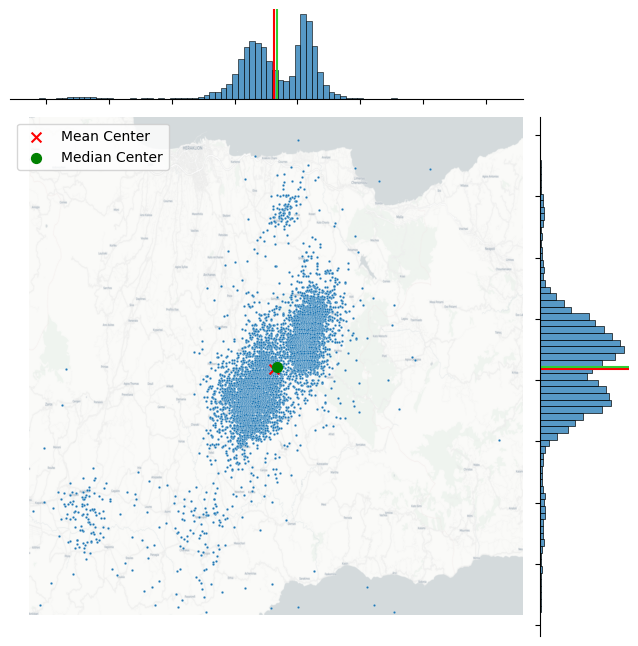

In [ ]:
# create joint plot with mean and median centers
joint_axes = sns.jointplot(
    data = eques_clip,
    x = eques_clip["geometry"].x,
    y = eques_clip["geometry"].y,
    s = 3,
    height = 7
)

joint_axes.ax_joint.scatter(
    *mean_center, color="red", marker="x", s=50, label="Mean Center"
)
joint_axes.ax_marg_x.axvline(mean_center[0],
                            color = "red")
joint_axes.ax_marg_y.axhline(mean_center[1],
                            color = "red")

joint_axes.ax_joint.scatter(
    *median_center, color="green", marker="o", s=50, label="Median Center"
)
joint_axes.ax_marg_x.axvline(median_center[0],
                            color = "limegreen")
joint_axes.ax_marg_y.axhline(median_center[1],
                            color = "limegreen")

joint_axes.ax_joint.set_axis_off()
    
ctx.add_basemap(joint_axes.ax_joint,
                crs="EPSG:4326",
                source=ctx.providers.CartoDB.Positron,
                zoom=12
)

joint_axes.ax_joint.legend();


In [89]:
def joint_plot(x, y, ax, ax_histx, ax_histy):
    ax_histx.tick_params(axis="both", labelleft=False, labelbottom=False)
    ax_histx.axis("off")
    ax_histy.tick_params(axis="both", labelleft=False, labelbottom=False)
    ax_histy.axis("off")

    ax.scatter(x, y, edgecolor='black', linewidth=0.08)
    ax.set_axis_off()
    
    ax_histx.hist(x, bins = 60, edgecolor='black', linewidth=0.3)
    ax_histy.hist(y, bins = 60, orientation='horizontal', edgecolor='black', linewidth=0.3)

    ctx.add_basemap(ax,
                    crs="EPSG:4326",
                    source = "Data/heraklion_positron.tif",
                    # source=ctx.providers.CartoDB.Positron,
                    # zoom=12
)

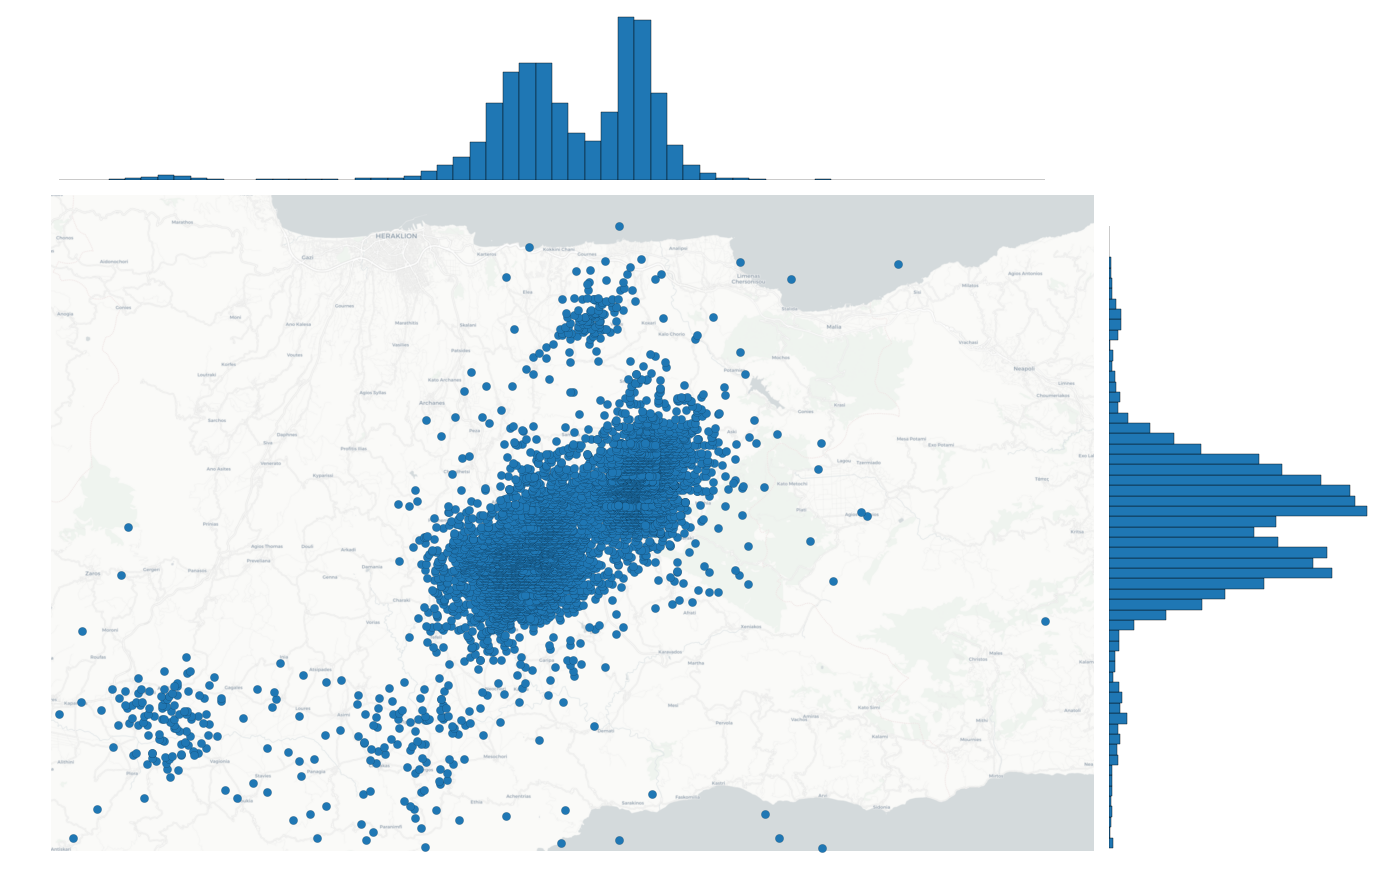

In [90]:
fig, axs = plt.subplot_mosaic([['histx', '.'],
                               ['scatter', 'histy']],
                               figsize=(14, 9),
                               width_ratios=(4, 1), height_ratios=(1, 4),
                               layout='tight')

joint_plot(eques_clip["geometry"].x,
           eques_clip["geometry"].y,
           axs['scatter'],
           axs['histx'],
           axs['histy']
)

In [ ]:
jan_aug = eques_gdf.loc[(eques_gdf["Date"] >= '2021-06-01')
                        & (eques_gdf["Date"] <= '2022-08-31')]
jan_aug

,Date,Time(GMT),Depth(km),Magnitude(Local),geometry
10236,2021-06-01,00:08:33.200000,9,1.9,POINT (2273745.127 4494911.17)
10237,2021-06-01,00:44:42.900000,31,2.4,POINT (2328937.331 4619127.189)
10238,2021-06-01,01:10:46.300000,23,2.0,POINT (2399001.818 4396206.542)
10239,2021-06-01,01:12:36,9,2.4,POINT (3028123.921 4360048.016)
10240,2021-06-01,01:50:24.400000,13,1.2,POINT (2405269.106 4656448.521)
...,...,...,...,...,...
39483,2022-08-31,23:06:43,10,1.3,POINT (2596159.768 4688165.461)
39484,2022-08-31,23:24:03.900000,7,1.2,POINT (2442828.302 4714669.486)
39485,2022-08-31,23:33:44.300000,44,2.2,POINT (2580107.498 4149784.07)
39486,2022-08-31,23:37:33.600000,37,2.1,POINT (2579907.123 4150530.578)
